# Exploratory Data Analysis 

## Phase 1: Dataset Overview & Basic Statistics

### 0. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

DATA_PATH = Path("../data/processed_dataset.npz")
FS = 125  
WINDOW_SEC = 5
WINDOW_SIZE = FS * WINDOW_SEC  

### 1.1 Load & Inspect

Load the three signal arrays from the `.npz` file and check shapes, data types, and memory usage.

In [2]:
data = np.load(DATA_PATH)
ppg = data["ppg"]
abp = data["abp"]
ecg = data["ecg"]

print("=== Dataset Shapes ===")
print(f"PPG: {ppg.shape}")
print(f"ABP: {abp.shape}")
print(f"ECG: {ecg.shape}")
print()
print("=== Data Types ===")
print(f"PPG dtype: {ppg.dtype}")
print(f"ABP dtype: {abp.dtype}")
print(f"ECG dtype: {ecg.dtype}")
print()
print("=== Memory Usage ===")
total_bytes = ppg.nbytes + abp.nbytes + ecg.nbytes
print(f"PPG: {ppg.nbytes / 1e9:.2f} GB")
print(f"ABP: {abp.nbytes / 1e9:.2f} GB")
print(f"ECG: {ecg.nbytes / 1e9:.2f} GB")
print(f"Total in memory: {total_bytes / 1e9:.2f} GB")
print()
print(f"Total windows: {ppg.shape[0]:,}")
print(f"Samples per window: {ppg.shape[1]}")
print(f"Duration per window: {ppg.shape[1] / FS:.1f} seconds")

=== Dataset Shapes ===
PPG: (528828, 625)
ABP: (528828, 625)
ECG: (528828, 625)

=== Data Types ===
PPG dtype: float64
ABP dtype: float64
ECG dtype: float64

=== Memory Usage ===
PPG: 2.64 GB
ABP: 2.64 GB
ECG: 2.64 GB
Total in memory: 7.93 GB

Total windows: 528,828
Samples per window: 625
Duration per window: 5.0 seconds


### 1.2 Missing & Anomalous Values

Check each signal for:
- **NaN** values (from incomplete windows padded during loading)
- **Inf** values (potential processing artifacts)
- **Constant / flat-line** rows (sensor disconnect when std ≈ 0)
- **All-zero** rows

In [3]:
def check_anomalies(arr, name):
    """Check a (n_windows, 625) array for NaN, Inf, flat-line, and all-zero rows."""
    n_total = arr.shape[0]
    
    nan_per_row = np.isnan(arr).any(axis=1)
    inf_per_row = np.isinf(arr).any(axis=1)
    std_per_row = np.nanstd(arr, axis=1)
    flatline = std_per_row < 1e-6
    all_zero = np.all(arr == 0, axis=1)
    
    results = {
        "signal": name,
        "total_windows": n_total,
        "nan_windows": int(nan_per_row.sum()),
        "inf_windows": int(inf_per_row.sum()),
        "flatline_windows (std < 1e-6)": int(flatline.sum()),
        "all_zero_windows": int(all_zero.sum()),
    }
    return results, nan_per_row, inf_per_row, flatline, all_zero

results_list = []
anomaly_masks = {}

for arr, name in [(ppg, "PPG"), (abp, "ABP"), (ecg, "ECG")]:
    res, nan_mask, inf_mask, flat_mask, zero_mask = check_anomalies(arr, name)
    results_list.append(res)
    anomaly_masks[name] = {
        "nan": nan_mask, "inf": inf_mask,
        "flatline": flat_mask, "all_zero": zero_mask
    }

anomaly_df = pd.DataFrame(results_list).set_index("signal")
anomaly_df

,total_windows,nan_windows,inf_windows,flatline_windows (std < 1e-6),all_zero_windows
signal,,,,,
PPG,528828,0,0,0,0
ABP,528828,0,0,0,0
ECG,528828,1,0,0,0


In [4]:
# Combined anomaly flag: a window is "bad" if ANY signal has NaN, Inf, or flat-line
any_bad = (
    anomaly_masks["PPG"]["nan"] | anomaly_masks["PPG"]["inf"] | anomaly_masks["PPG"]["flatline"] |
    anomaly_masks["ABP"]["nan"] | anomaly_masks["ABP"]["inf"] | anomaly_masks["ABP"]["flatline"]
)

print(f"Windows with ANY anomaly (PPG or ABP): {any_bad.sum():,} / {len(any_bad):,} ({any_bad.mean()*100:.2f}%)")
print(f"Clean windows: {(~any_bad).sum():,} ({(~any_bad).mean()*100:.2f}%)")

Windows with ANY anomaly (PPG or ABP): 0 / 528,828 (0.00%)
Clean windows: 528,828 (100.00%)


### 1.3 Per-Window Summary Statistics

Compute basic statistics per window for PPG and ABP to understand value ranges and distributions.

In [5]:
def compute_window_stats(arr, name):
    """Compute per-window summary stats for a (n_windows, 625) array."""
    stats = pd.DataFrame({
        f"{name}_mean": np.nanmean(arr, axis=1),
        f"{name}_std": np.nanstd(arr, axis=1),
        f"{name}_min": np.nanmin(arr, axis=1),
        f"{name}_max": np.nanmax(arr, axis=1),
        f"{name}_median": np.nanmedian(arr, axis=1),
        f"{name}_range": np.nanmax(arr, axis=1) - np.nanmin(arr, axis=1),
    })
    return stats

ppg_stats = compute_window_stats(ppg, "PPG")
abp_stats = compute_window_stats(abp, "ABP")

window_stats = pd.concat([ppg_stats, abp_stats], axis=1)
print(f"Window stats shape: {window_stats.shape}")
window_stats.describe().round(3)

Window stats shape: (528828, 12)


,PPG_mean,PPG_std,PPG_min,PPG_max,PPG_median,PPG_range,ABP_mean,ABP_std,ABP_min,ABP_max,ABP_median,ABP_range
count,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000,528828.000
mean,1.588,0.536,0.826,2.766,1.430,1.939,88.807,19.905,64.413,132.955,82.034,68.542
std,0.472,0.168,0.294,0.821,0.444,0.630,13.802,6.321,10.990,22.787,13.435,19.935
min,0.301,0.020,0.000,0.500,0.273,0.098,58.022,1.246,50.000,63.364,53.924,5.129
25%,1.648,0.529,0.811,2.963,1.393,1.978,78.402,15.656,56.229,115.907,72.045,54.998
50%,1.746,0.591,0.947,3.032,1.546,2.075,86.709,19.379,62.032,131.098,79.791,67.503
75%,1.829,0.635,0.991,3.118,1.686,2.207,97.025,23.744,70.042,148.017,89.971,81.433
max,2.596,1.405,1.621,4.003,2.838,4.002,189.306,54.333,184.514,199.987,188.683,148.486


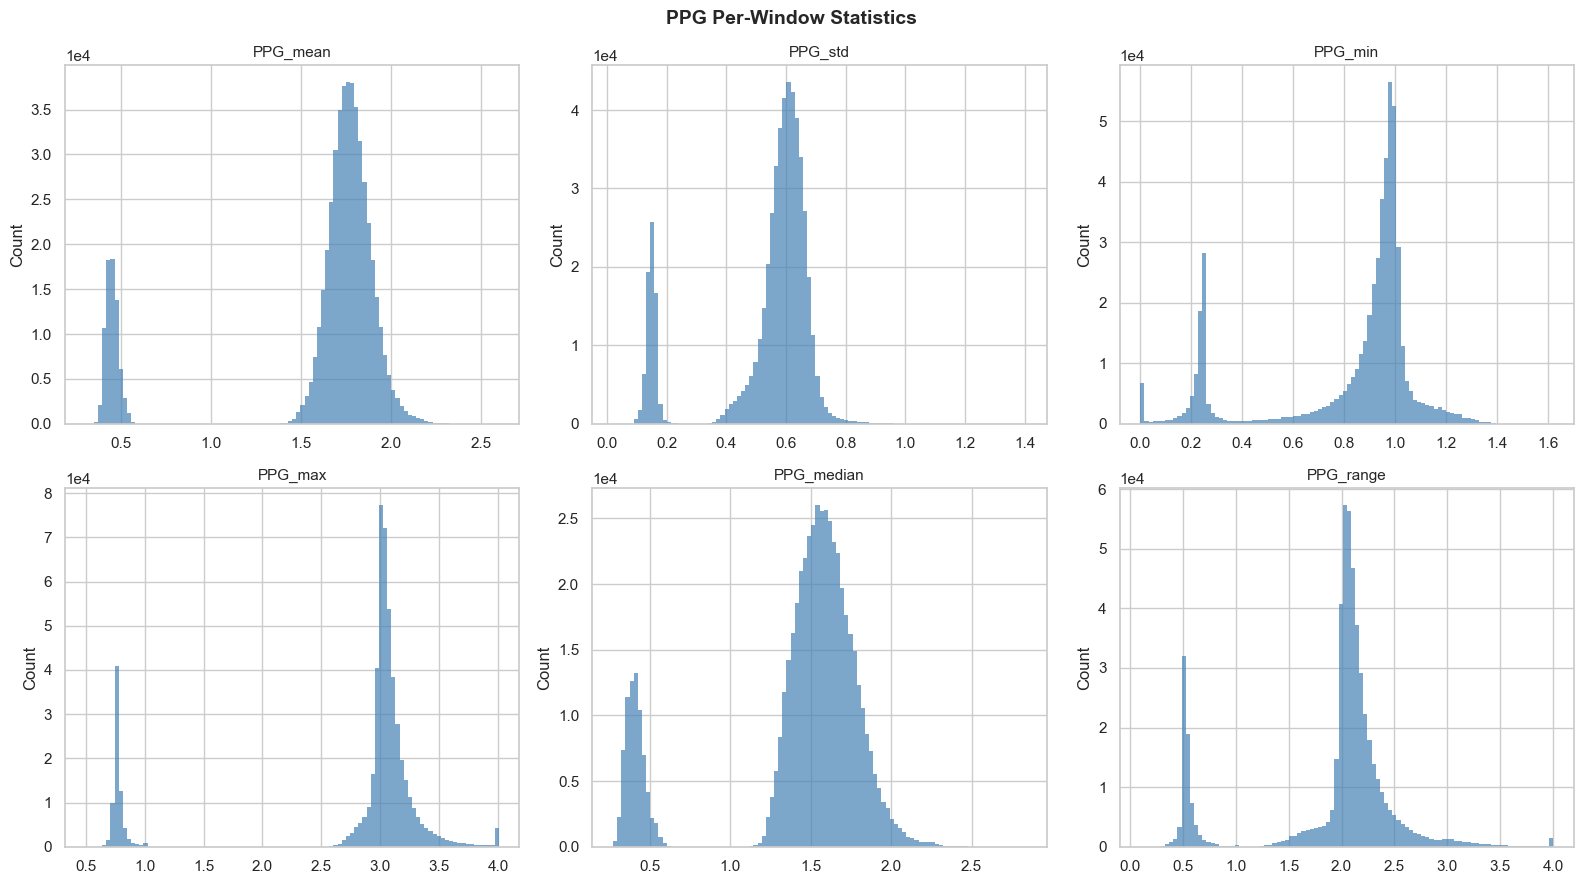

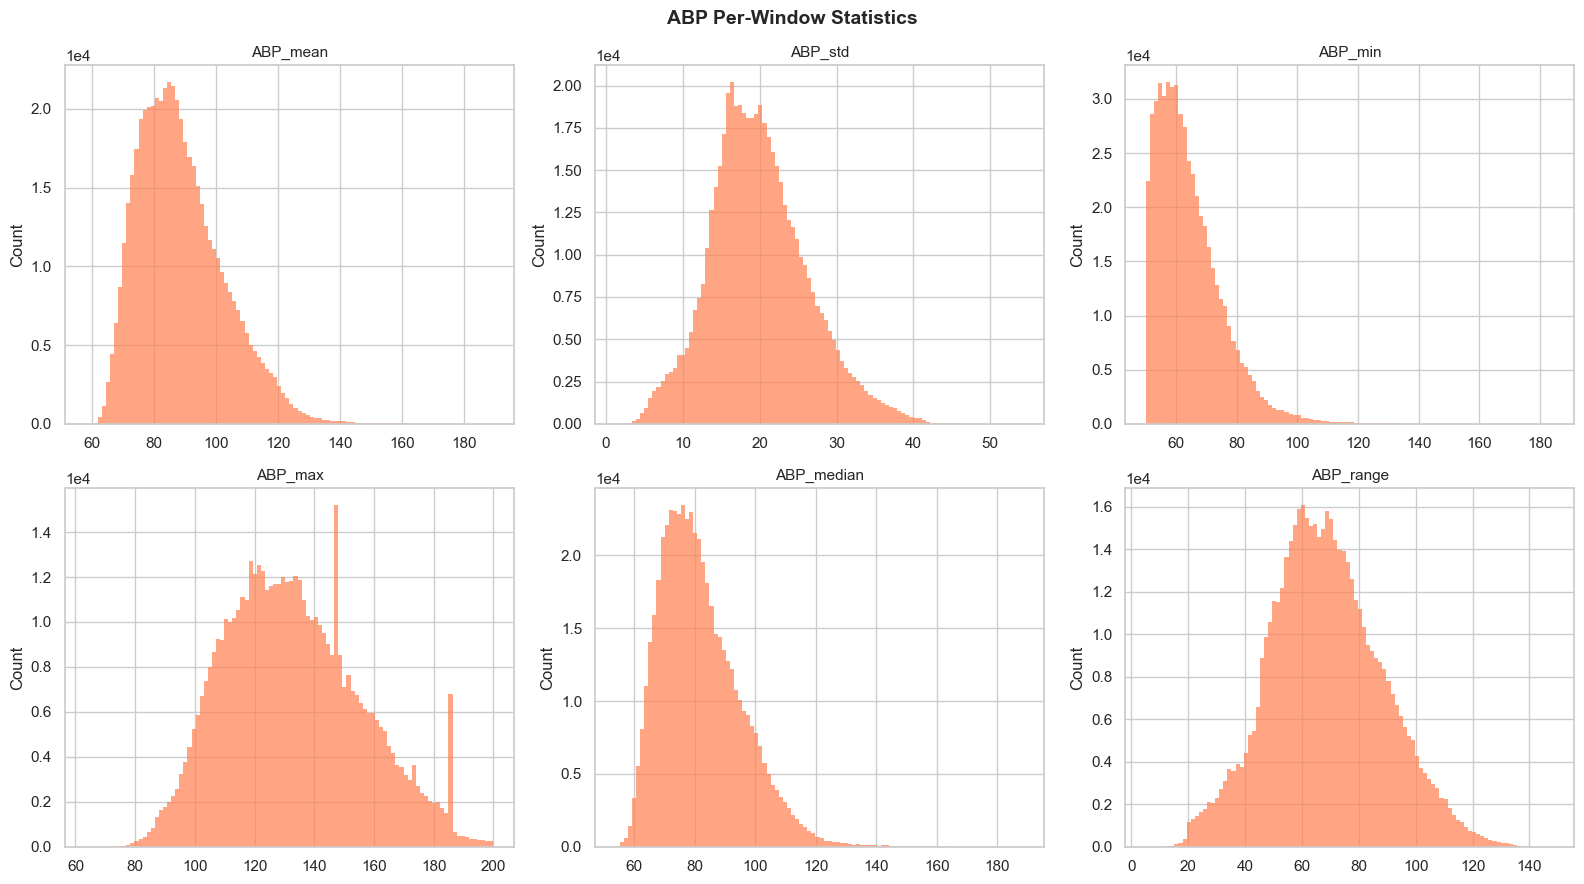

In [6]:
# Visualize distributions of ABP and PPG per-window statistics
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("PPG Per-Window Statistics", fontsize=14, fontweight="bold")

for i, col in enumerate(ppg_stats.columns):
    row, c = divmod(i, 3)
    ax = axes[row, c]
    ax.hist(ppg_stats[col].dropna(), bins=100, alpha=0.7, color="steelblue", edgecolor="none")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Count")
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0,0))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("ABP Per-Window Statistics", fontsize=14, fontweight="bold")

for i, col in enumerate(abp_stats.columns):
    row, c = divmod(i, 3)
    ax = axes[row, c]
    ax.hist(abp_stats[col].dropna(), bins=100, alpha=0.7, color="coral", edgecolor="none")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Count")
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0,0))

plt.tight_layout()
plt.show()

### 1.4 Extract SBP & DBP Labels

In [ ]:
def extract_bp_labels(abp_window):
    """Extract SBP (mean of peaks) and DBP (mean of valleys) from a single ABP window."""
    peaks, _ = find_peaks(abp_window)
    valleys, _ = find_peaks(-abp_window)
    
    sbp = np.mean(abp_window[peaks]) if len(peaks) > 0 else np.nan
    dbp = np.mean(abp_window[valleys]) if len(valleys) > 0 else np.nan
    n_peaks = len(peaks)
    n_valleys = len(valleys)
    
    return sbp, dbp, n_peaks, n_valleys


n_windows = abp.shape[0]
sbp_arr = np.full(n_windows, np.nan)
dbp_arr = np.full(n_windows, np.nan)
n_peaks_arr = np.zeros(n_windows, dtype=int)
n_valleys_arr = np.zeros(n_windows, dtype=int)

for i in range(n_windows):
    if i % 100_000 == 0:
        print(f"  Processing window {i:,} / {n_windows:,} ...")
    sbp_arr[i], dbp_arr[i], n_peaks_arr[i], n_valleys_arr[i] = extract_bp_labels(abp[i])

print("Done!")

Extracting SBP/DBP from ABP windows... (this may take several minutes)
  Processing window 0 / 528,828 ...
  Processing window 100,000 / 528,828 ...
  Processing window 200,000 / 528,828 ...
  Processing window 300,000 / 528,828 ...
  Processing window 400,000 / 528,828 ...
  Processing window 500,000 / 528,828 ...
Done!


In [8]:
# Combine labels into a DataFrame
labels_df = pd.DataFrame({
    "SBP": sbp_arr,
    "DBP": dbp_arr,
    "PP": sbp_arr - dbp_arr,   # Pulse Pressure
    "MAP": dbp_arr + (sbp_arr - dbp_arr) / 3,  # Mean Arterial Pressure
    "n_peaks": n_peaks_arr,
    "n_valleys": n_valleys_arr
})

print(f"Labels shape: {labels_df.shape}")
print(f"\nNaN counts:")
print(labels_df.isna().sum())
print(f"\nBasic statistics:")
labels_df.describe().round(2)

Labels shape: (528828, 6)

NaN counts:
SBP          3
DBP          3
PP           3
MAP          3
n_peaks      0
n_valleys    0
dtype: int64

Basic statistics:


,SBP,DBP,PP,MAP,n_peaks,n_valleys
count,528825.00,528825.00,528825.00,528825.00,528828.00,528828.00
mean,112.05,72.71,39.34,85.83,14.26,14.26
std,20.99,13.81,18.60,14.04,6.47,6.47
min,58.10,50.09,0.07,56.15,0.00,0.00
25%,96.50,62.60,26.88,75.38,9.00,9.00
50%,109.14,69.89,35.69,83.55,14.00,14.00
75%,125.33,79.81,47.70,94.02,17.00,17.00
max,199.37,189.18,134.35,189.37,103.00,104.00


In [9]:
# Quick sanity check: SBP should be > DBP for valid readings
valid_mask = labels_df["SBP"].notna() & labels_df["DBP"].notna()
sbp_gt_dbp = (labels_df.loc[valid_mask, "SBP"] > labels_df.loc[valid_mask, "DBP"]).sum()
sbp_le_dbp = (labels_df.loc[valid_mask, "SBP"] <= labels_df.loc[valid_mask, "DBP"]).sum()

print(f"Windows with valid SBP & DBP: {valid_mask.sum():,}")
print(f"  SBP > DBP (correct): {sbp_gt_dbp:,} ({sbp_gt_dbp/valid_mask.sum()*100:.2f}%)")
print(f"  SBP ≤ DBP (problematic): {sbp_le_dbp:,} ({sbp_le_dbp/valid_mask.sum()*100:.2f}%)")

Windows with valid SBP & DBP: 528,825
  SBP > DBP (correct): 528,825 (100.00%)
  SBP ≤ DBP (problematic): 0 (0.00%)


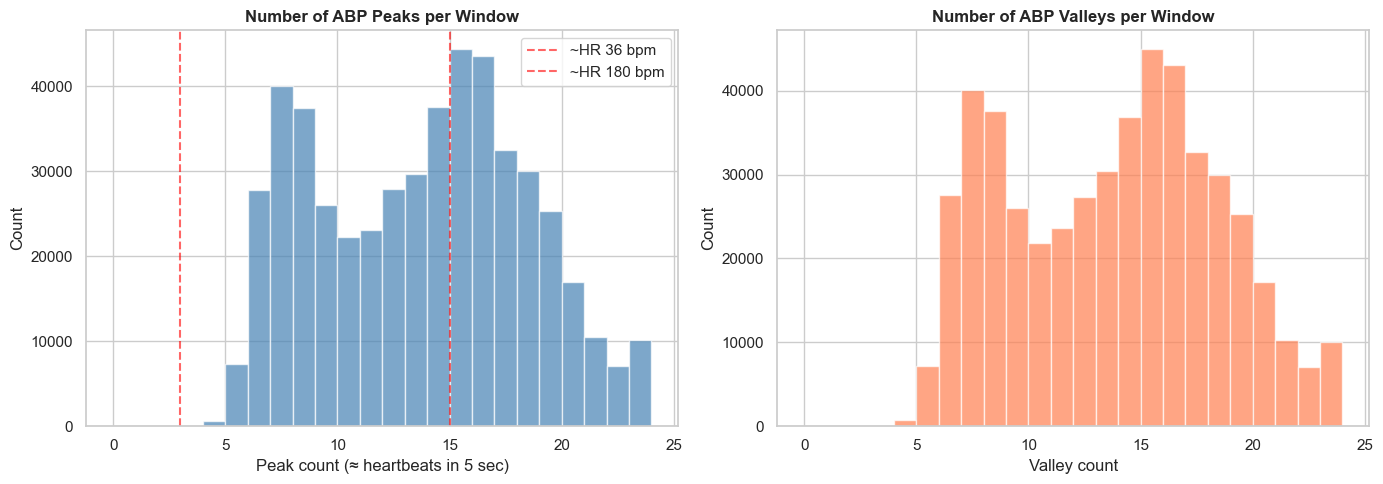

Estimated HR (from ABP peaks): mean=171.1, median=168.0, min=0, max=1236 bpm


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(labels_df["n_peaks"], bins=range(0, 25), alpha=0.7, color="steelblue", edgecolor="white")
axes[0].set_title("Number of ABP Peaks per Window", fontweight="bold")
axes[0].set_xlabel("Peak count (≈ heartbeats in 5 sec)")
axes[0].set_ylabel("Count")
axes[0].axvline(x=3, color="red", linestyle="--", alpha=0.6, label="~HR 36 bpm")
axes[0].axvline(x=15, color="red", linestyle="--", alpha=0.6, label="~HR 180 bpm")
axes[0].legend()

axes[1].hist(labels_df["n_valleys"], bins=range(0, 25), alpha=0.7, color="coral", edgecolor="white")
axes[1].set_title("Number of ABP Valleys per Window", fontweight="bold")
axes[1].set_xlabel("Valley count")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

est_hr = labels_df["n_peaks"] / WINDOW_SEC * 60  # peaks per 5s → bpm
print(f"Estimated heart rate (from ABP peaks): mean={est_hr.mean():.1f}, median={est_hr.median():.1f}, "
      f"min={est_hr.min():.0f}, max={est_hr.max():.0f} bpm")

### 1.5 Phase 1 Summary

Key findings from Phase 1 will be filled in after running the cells above:

- **Dataset size**: 528828 windows × 625 samples
- **Missing/anomalous windows**: 4 total bad windows (1 NaN from raw ECG signal, 3 NaNs from failed ABP target feature (sbp and dbp) extraction)
- **PPG value range**: 0.826 to 2.766
- **ABP value range**: 64.413 to 132.955 mmHg
- **SBP**: mean 112.05, std 20.99, range 58.10 to 199.37
- **DBP**: mean 72.71, std 13.81, range 50.09 to 189.18
- **Windows where SBP ≤ DBP**: N/A 
- **Estimated heart rate range**: 0 to 1236 bpm

---